In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/income_tax.csv')
df

,Tax Year,Resident Type,Place of Residence,Country,State,County,Income Class,Disclosure,Number of All Returns,NY AGI of All Returns (in thousands) *,Deductions of All Returns (in thousands),Dependent Exemptions of All Returns (in thousands),Taxable Income of All Returns (in thousands),Tax Before Credits of All Returns (in thousands),Tax Liability of All Returns (in thousands) **,Place of Residence Sort Order,Income Class Sort Order
0,2012,Full-Year Nonresident,Ireland,Ireland,Not Applicable,Not Applicable,"40,000 - 49,999",d/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205,6
1,2012,Full-Year Nonresident,Ireland,Ireland,Not Applicable,Not Applicable,"50,000 - 59,999",d/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205,7
2,2012,Full-Year Nonresident,Ireland,Ireland,Not Applicable,Not Applicable,"60,000 - 74,999",d/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205,8
3,2012,Full-Year Nonresident,A.P.O./F.P.O,A.P.O./F.P.O,All,All,"Under 5,000",NaN,632.0,-2644.0,105.0,0.0,2.0,0.0,0.0,150,1
4,2012,Full-Year Nonresident,A.P.O./F.P.O,A.P.O./F.P.O,All,All,"5,000 - 9,999",NaN,58.0,433.0,255.0,0.0,21.0,1.0,1.0,150,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23730,2014,Full-Year Nonresident,Illinois,United States,Illinois,All,"Under 5,000",NaN,651.0,-468804.0,1014.0,0.0,118.0,5.0,1.0,113,1
23731,2014,Full-Year Resident,Madison,United States,New York,Madison,"50,000 - 59,999",NaN,1803.0,98697.0,23681.0,1173.0,73843.0,3857.0,3435.0,31,7
23732,2014,Full-Year Nonresident,Maine,United States,Maine,All,"250,000 - 499,999",NaN,196.0,67186.0,4485.0,127.0,51248.0,3465.0,1102.0,119,12
23733,2014,Full-Year Nonresident,Virginia,United States,Virginia,All,"10,000 - 19,999",NaN,867.0,12917.0,6028.0,122.0,4561.0,188.0,98.0,145,3


In [ ]:
df.head()

,Tax Year,Resident Type,Place of Residence,Country,State,County,Income Class,Disclosure,Number of All Returns,NY AGI of All Returns (in thousands) *,Deductions of All Returns (in thousands),Dependent Exemptions of All Returns (in thousands),Taxable Income of All Returns (in thousands),Tax Before Credits of All Returns (in thousands),Tax Liability of All Returns (in thousands) **,Place of Residence Sort Order,Income Class Sort Order
0,2012,Full-Year Nonresident,Ireland,Ireland,Not Applicable,Not Applicable,"40,000 - 49,999",d/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205,6
1,2012,Full-Year Nonresident,Ireland,Ireland,Not Applicable,Not Applicable,"50,000 - 59,999",d/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205,7
2,2012,Full-Year Nonresident,Ireland,Ireland,Not Applicable,Not Applicable,"60,000 - 74,999",d/,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205,8
3,2012,Full-Year Nonresident,A.P.O./F.P.O,A.P.O./F.P.O,All,All,"Under 5,000",NaN,632.0,-2644.0,105.0,0.0,2.0,0.0,0.0,150,1
4,2012,Full-Year Nonresident,A.P.O./F.P.O,A.P.O./F.P.O,All,All,"5,000 - 9,999",NaN,58.0,433.0,255.0,0.0,21.0,1.0,1.0,150,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23735 entries, 0 to 23734
Data columns (total 17 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Tax Year                                            23735 non-null  int64  
 1   Resident Type                                       23735 non-null  object 
 2   Place of Residence                                  23735 non-null  object 
 3   Country                                             23735 non-null  object 
 4   State                                               23735 non-null  object 
 5   County                                              23735 non-null  object 
 6   Income Class                                        23735 non-null  object 
 7   Disclosure                                          296 non-null    object 
 8   Number of All Returns                               23439 non-null  float64


#Data Standardization


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.lower()
)
df.rename(columns={
    'Resident Type': 'resident_type',
    'Tax Year': 'tax_year',
    'Place of Residence': 'place_of_residence',
    'Country': 'country',
    'State': 'state',
    'Income Class': 'income_class',
    'Number of All Returns': 'number_of_all_returns'

}, inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23735 entries, 0 to 23734
Data columns (total 17 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   tax_year                                            23735 non-null  int64  
 1   resident_type                                       23735 non-null  object 
 2   place_of_residence                                  23735 non-null  object 
 3   country                                             23735 non-null  object 
 4   state                                               23735 non-null  object 
 5   county                                              23735 non-null  object 
 6   income_class                                        23735 non-null  object 
 7   disclosure                                          296 non-null    object 
 8   number_of_all_returns                               23439 non-null  float64


In [ ]:
def makenan(value):
  if value <= 0:
    return np.nan
  else:
    return value

def makenan1(value):
  if value < 0:
    return np.nan
  else:
    return value

df['number_of_all_returns'] = df['number_of_all_returns'].apply(makenan)
df['deductions_of_all_returns_(in_thousands)'] = df['deductions_of_all_returns_(in_thousands)'].apply(makenan)
df['dependent_exemptions_of_all_returns_(in_thousands)'] = df['dependent_exemptions_of_all_returns_(in_thousands)'].apply(makenan)
df['taxable_income_of_all_returns_(in_thousands)'] = df['taxable_income_of_all_returns_(in_thousands)'].apply(makenan)
df['tax_before_credits_of_all_returns_(in_thousands)'] = df['tax_before_credits_of_all_returns_(in_thousands)'].apply(makenan)
df['place_of_residence_sort_order'] = df['place_of_residence_sort_order'].apply(makenan)
df['income_class_sort_order'] = df['income_class_sort_order'].apply(makenan)


#EDA

#Univariate Analysis (numerical)



% of missing values in the number_of_all_returns:
1.2555298082999788

descriptive stats for number_of_all_returns:
count    2.343700e+04
mean     2.531457e+04
std      2.385721e+05
min      1.000000e+01
25%      2.210000e+02
50%      1.619000e+03
75%      5.997000e+03
max      9.082186e+06
Name: number_of_all_returns, dtype: float64

skewness of the number_of_all_returns:
30.50288847180983

distribution of the number_of_all_returns:


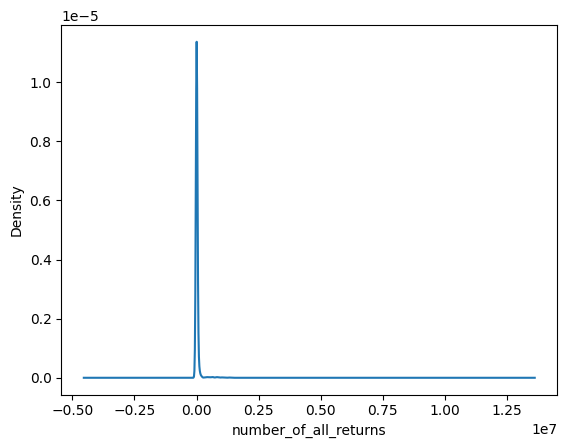


number_of_all_returns is not normally distributed

number_of_all_returns has 16.09% outliers

% of missing values in the ny_agi_of_all_returns_(in_thousands)_*:
1.24710343374763

descriptive stats for ny_agi_of_all_returns_(in_thousands)_*:
count    2.343900e+04
mean     2.137719e+06
std      1.834359e+07
min     -1.370167e+07
25%      1.088650e+04
50%      7.498000e+04
75%      3.659255e+05
max      6.736595e+08
Name: ny_agi_of_all_returns_(in_thousands)_*, dtype: float64

skewness of the ny_agi_of_all_returns_(in_thousands)_*:
21.822416921250753

distribution of the ny_agi_of_all_returns_(in_thousands)_*:


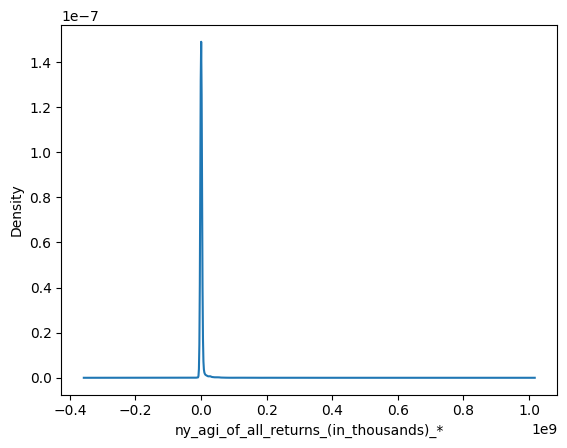


ny_agi_of_all_returns_(in_thousands)_* is not normally distributed

ny_agi_of_all_returns_(in_thousands)_* has 17.05% outliers

% of missing values in the deductions_of_all_returns_(in_thousands):
1.2555298082999788

descriptive stats for deductions_of_all_returns_(in_thousands):
count    2.343700e+04
mean     3.229281e+05
std      2.876410e+06
min      7.000000e+00
25%      2.882000e+03
50%      1.913500e+04
75%      7.291200e+04
max      1.092628e+08
Name: deductions_of_all_returns_(in_thousands), dtype: float64

skewness of the deductions_of_all_returns_(in_thousands):
28.883834808910606

distribution of the deductions_of_all_returns_(in_thousands):


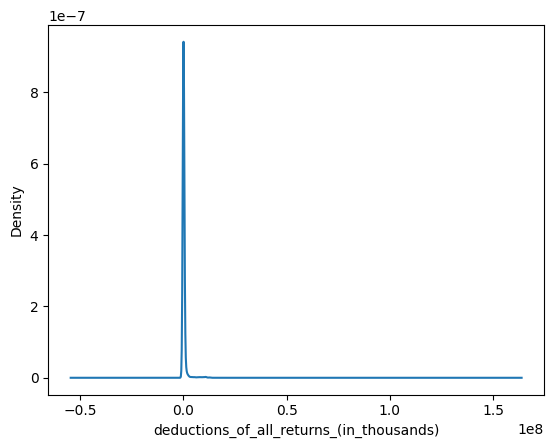


deductions_of_all_returns_(in_thousands) is not normally distributed

deductions_of_all_returns_(in_thousands) has 15.88% outliers

% of missing values in the dependent_exemptions_of_all_returns_(in_thousands):
9.298504318516958

descriptive stats for dependent_exemptions_of_all_returns_(in_thousands):
count    2.152800e+04
mean     1.536976e+04
std      1.369164e+05
min      1.000000e+00
25%      7.800000e+01
50%      8.760000e+02
75%      3.510000e+03
max      4.720151e+06
Name: dependent_exemptions_of_all_returns_(in_thousands), dtype: float64

skewness of the dependent_exemptions_of_all_returns_(in_thousands):
28.34771887440536

distribution of the dependent_exemptions_of_all_returns_(in_thousands):


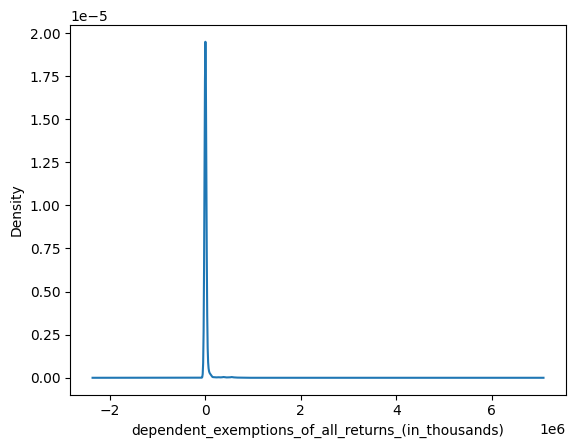


dependent_exemptions_of_all_returns_(in_thousands) is not normally distributed

dependent_exemptions_of_all_returns_(in_thousands) has 14.19% outliers

% of missing values in the taxable_income_of_all_returns_(in_thousands):
1.4914682957657468

descriptive stats for taxable_income_of_all_returns_(in_thousands):
count    2.338100e+04
mean     1.756429e+06
std      1.535416e+07
min      1.000000e+00
25%      4.881000e+03
50%      4.853900e+04
75%      2.601850e+05
max      5.755124e+08
Name: taxable_income_of_all_returns_(in_thousands), dtype: float64

skewness of the taxable_income_of_all_returns_(in_thousands):
21.332131475173632

distribution of the taxable_income_of_all_returns_(in_thousands):


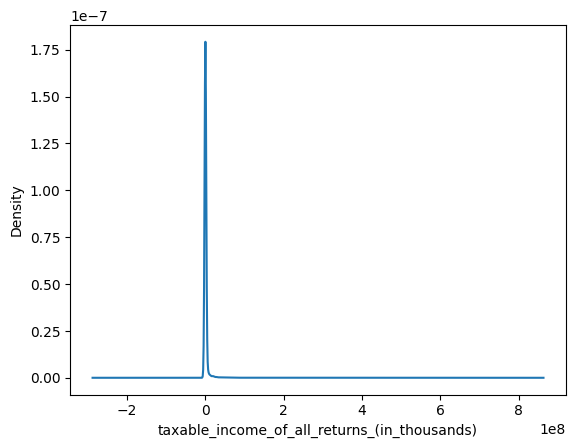


taxable_income_of_all_returns_(in_thousands) is not normally distributed

taxable_income_of_all_returns_(in_thousands) has 16.78% outliers

% of missing values in the tax_before_credits_of_all_returns_(in_thousands):
2.2287760690962712

descriptive stats for tax_before_credits_of_all_returns_(in_thousands):
count    2.320600e+04
mean     1.216376e+05
std      1.085061e+06
min      1.000000e+00
25%      2.580000e+02
50%      2.649500e+03
75%      1.567675e+04
max      3.912255e+07
Name: tax_before_credits_of_all_returns_(in_thousands), dtype: float64

skewness of the tax_before_credits_of_all_returns_(in_thousands):
20.28839116147013

distribution of the tax_before_credits_of_all_returns_(in_thousands):


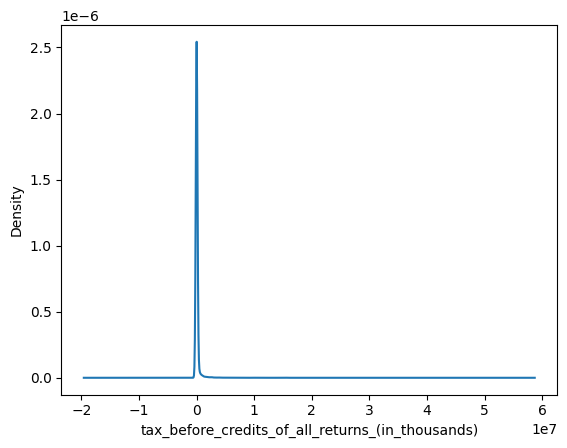


tax_before_credits_of_all_returns_(in_thousands) is not normally distributed

tax_before_credits_of_all_returns_(in_thousands) has 16.73% outliers

% of missing values in the tax_liability_of_all_returns_(in_thousands)_**:
1.24710343374763

descriptive stats for tax_liability_of_all_returns_(in_thousands)_**:
count    2.343900e+04
mean     8.154471e+04
std      8.377998e+05
min     -4.674790e+05
25%      3.600000e+01
50%      1.365000e+03
75%      8.602500e+03
max      3.501178e+07
Name: tax_liability_of_all_returns_(in_thousands)_**, dtype: float64

skewness of the tax_liability_of_all_returns_(in_thousands)_**:
24.70012600815387

distribution of the tax_liability_of_all_returns_(in_thousands)_**:


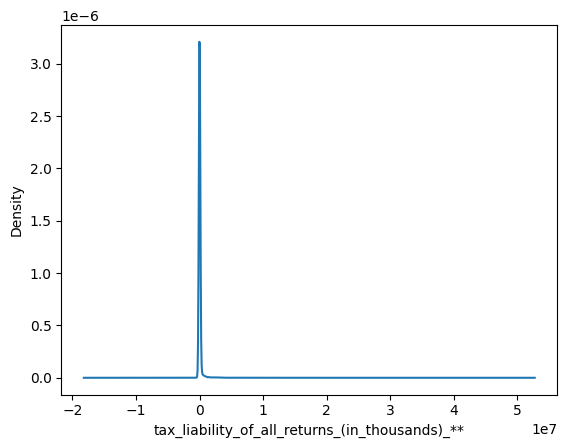


tax_liability_of_all_returns_(in_thousands)_** is not normally distributed

tax_liability_of_all_returns_(in_thousands)_** has 17.07% outliers


In [ ]:
num_col = ['number_of_all_returns', 'ny_agi_of_all_returns_(in_thousands)_*', 'deductions_of_all_returns_(in_thousands)', 'dependent_exemptions_of_all_returns_(in_thousands)', 'taxable_income_of_all_returns_(in_thousands)', 'tax_before_credits_of_all_returns_(in_thousands)', 'tax_liability_of_all_returns_(in_thousands)_**']

for col in num_col:
  print(f'\n% of missing values in the {col}:')
  print(df[col].isnull().mean()*100)
  print(f'\ndescriptive stats for {col}:')
  print(df[col].describe())
  print(f'\nskewness of the {col}:')
  print(df[col].skew())
  print(f'\ndistribution of the {col}:')
  df[col].plot(kind='kde')
  plt.xlabel(col)
  plt.show()
  if df[col].skew()<=1 and df[col].skew()>=-1:
    print(f'\n{col} is normally distributed')
    #Z-SCORE METHOD
    min = df[col].mean() - 3*df[col].std()
    max = df[col].mean() + 3*df[col].std()
    df_outlier = df[(df[col] < min) | (df[col] > max)]
    percent_of_outliers = df_outlier.shape[0]*100/df.shape[0]
    print(f'\n{col} has {percent_of_outliers:.2f}% outliers')
  else:
    print(f'\n{col} is not normally distributed')
    #IQR METHOD
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    min = Q1 - 1.5*IQR
    max = Q3 + 1.5*IQR
    df_outlier = df[(df[col] < min) | (df[col] > max)]
    percent_of_outliers = df_outlier.shape[0]*100/df.shape[0]
    print(f'\n{col} has {percent_of_outliers:.2f}% outliers')

#Univariate Analysis (categorical)


Number of missing values in resident_type:
0

Number of unique categories in resident_type:
3

Frequency Distribution of resident_type:
resident_type
Full-Year Resident       0.569412
Full-Year Nonresident    0.421824
Part-Year Resident       0.008763
Name: proportion, dtype: float64


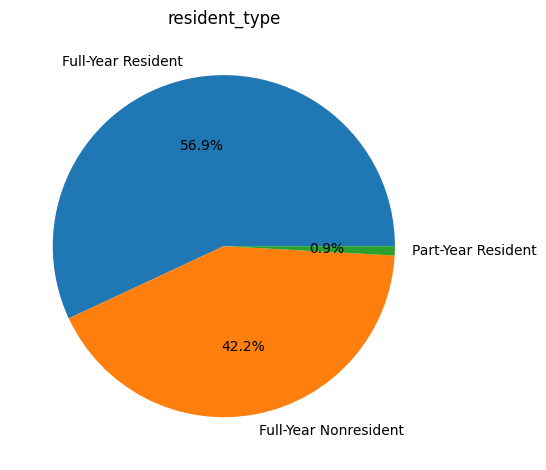


Number of missing values in place_of_residence:
0

Number of unique categories in place_of_residence:
131

Frequency Distribution of top 10 in place_of_residence (including 'Other'):
place_of_residence
Other                     0.892943
Washington                0.017527
Delaware                  0.017021
Wyoming                   0.011123
Hamilton                  0.008806
Residence Unknown ++++    0.008763
Canada                    0.008763
Onondaga                  0.008763
Saratoga                  0.008763
Otsego                    0.008763
Broome                    0.008763
Name: proportion, dtype: float64


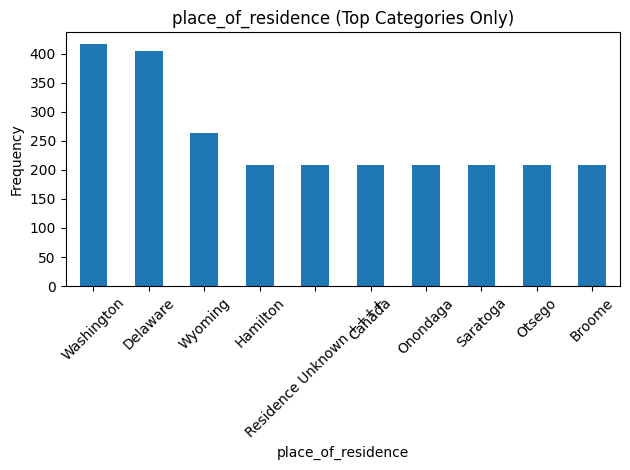


Number of missing values in country:
0

Number of unique categories in country:
18

Frequency Distribution of top 10 in country (including 'Other'):
country
United States              0.899979
Other                      0.022709
All                        0.017527
All Other Countries +++    0.008763
Canada                     0.008763
Residence Unknown ++++     0.008763
Germany                    0.008258
Ireland                    0.008216
China                      0.006657
France                     0.005393
Japan                      0.004972
Name: proportion, dtype: float64


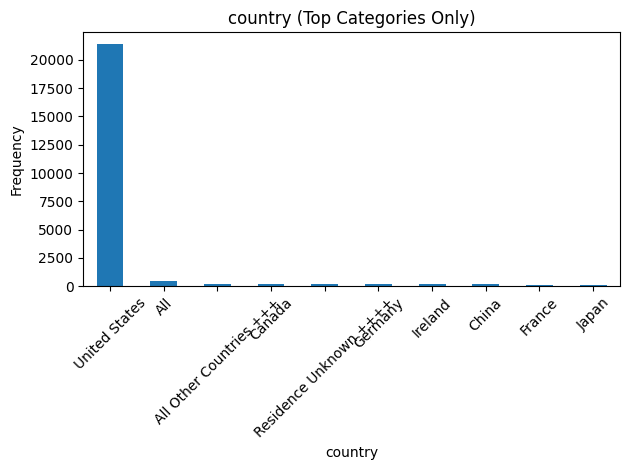


Number of missing values in state:
0

Number of unique categories in state:
55

Frequency Distribution of top 10 in state (including 'Other'):
state
New York                    0.569412
Other                       0.271582
Not Applicable              0.080135
All - Excluding New York    0.017527
Washington                  0.008763
Pennsylvania                0.008763
Texas                       0.008763
Massachusetts               0.008763
Rhode Island                0.008763
Illinois                    0.008763
Virginia                    0.008763
Name: proportion, dtype: float64


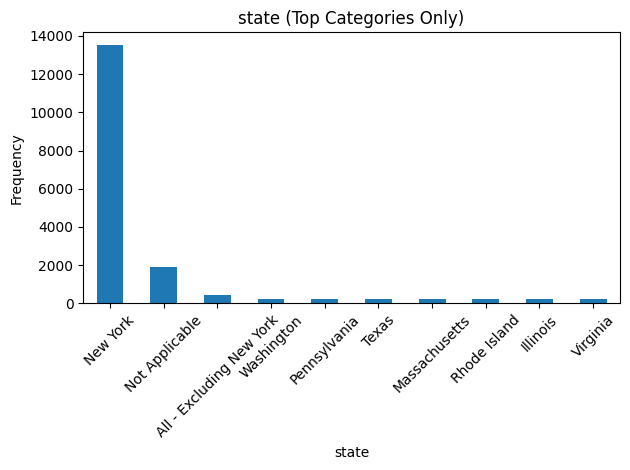


Number of missing values in county:
0

Number of unique categories in county:
74

Frequency Distribution of top 10 in county (including 'Other'):
county
Other                                 0.516790
All                                   0.332926
Not Applicable                        0.080135
Hamilton                              0.008806
Grand Total, Full-Year Nonresident    0.008763
Orleans                               0.008763
Grand Total, Part-Year Resident       0.008763
Washington                            0.008763
Dutchess                              0.008763
Ontario                               0.008763
Clinton                               0.008763
Name: proportion, dtype: float64


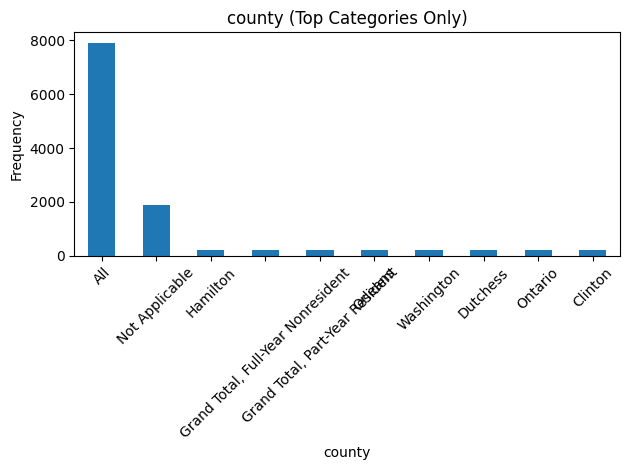


Number of missing values in income_class:
0

Number of unique categories in income_class:
15

Frequency Distribution of top 10 in income_class (including 'Other'):
income_class
Other                0.234885
40,000 - 49,999      0.076511
60,000 - 74,999      0.076511
Under 5,000          0.076511
5,000 - 9,999        0.076511
10,000 - 19,999      0.076511
20,000 - 29,999      0.076511
30,000 - 39,999      0.076511
75,000 - 99,999      0.076511
100,000 - 199,999    0.076511
Total                0.076511
Name: proportion, dtype: float64


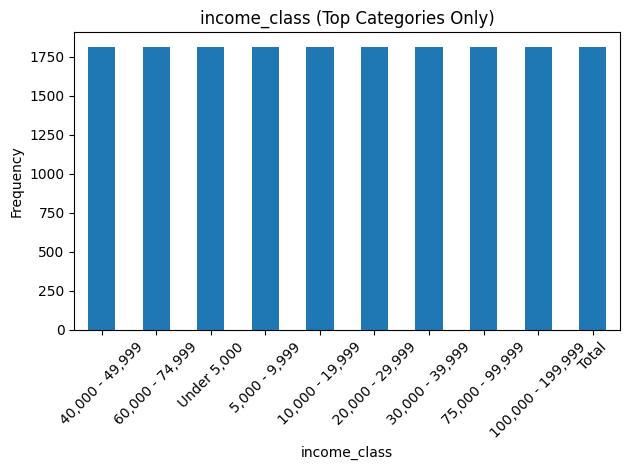

In [ ]:
cat_col = ['resident_type', 'place_of_residence', 'country', 'state', 'county', 'income_class']

for col in cat_col:
   print(f"\nNumber of missing values in {col}:")
   print(df[df[col]=='missing'][col].count())
   print(f"\nNumber of unique categories in {col}:")
   num_unique = df[col].nunique()
   print(num_unique)


   if num_unique > 10:
        print(f"\nFrequency Distribution of top 10 in {col} (including 'Other'):")

        top10 = df[col].value_counts(normalize=True).nlargest(10)

        temp_col = df[col].apply(lambda x: x if x in top10 else 'Other')

        freq = temp_col.value_counts(normalize=True)
        print(freq)

        plot_data = temp_col[temp_col != 'Other'].value_counts()
        plot_data.plot(kind='bar', title=f"{col} (Top Categories Only)")
        plt.ylabel("Frequency")
        plt.xticks(rotation=45)
        plt.tight_layout()
        #plt.savefig(f"{col}_CAT_univar.png", dpi=300, bbox_inches="tight")  # save as PNG
        plt.show()

   else:
        print(f"\nFrequency Distribution of {col}:")
        print(df[col].value_counts(normalize=True))
        df[col].value_counts().plot(kind='pie', autopct='%0.1f%%', title=col)
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig(f"{col}_CAT_univar.png", dpi=300, bbox_inches="tight")  # save as PNG
        plt.show()

#Data Cleaning

# 1] Handling missing values

i) Numerical

In [ ]:
num_col = ['number_of_all_returns', 'ny_agi_of_all_returns_(in_thousands)_*', 'deductions_of_all_returns_(in_thousands)', 'dependent_exemptions_of_all_returns_(in_thousands)', 'taxable_income_of_all_returns_(in_thousands)', 'tax_before_credits_of_all_returns_(in_thousands)', 'tax_liability_of_all_returns_(in_thousands)_**']

for col in num_col:
  if df[col].isnull().mean()*100 < 5:
    df.dropna(subset=[col], inplace=True)
  else:
    if df[col].skew()<=1 and df[col].skew()>=-1:
      df[col].fillna(df[col].mean(), inplace=True)
    else:
      df[col].fillna(df[col].median(), inplace=True)


/tmp/ipython-input-557903748.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23206 entries, 4 to 23734
Data columns (total 17 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   tax_year                                            23206 non-null  int64  
 1   resident_type                                       23206 non-null  object 
 2   place_of_residence                                  23206 non-null  object 
 3   country                                             23206 non-null  object 
 4   state                                               23206 non-null  object 
 5   county                                              23206 non-null  object 
 6   income_class                                        23206 non-null  object 
 7   disclosure                                          0 non-null      object 
 8   number_of_all_returns                               23206 non-null  float64
 9   

In [ ]:
df.drop(columns=['disclosure'],inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23206 entries, 4 to 23734
Data columns (total 16 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   tax_year                                            23206 non-null  int64  
 1   resident_type                                       23206 non-null  object 
 2   place_of_residence                                  23206 non-null  object 
 3   country                                             23206 non-null  object 
 4   state                                               23206 non-null  object 
 5   county                                              23206 non-null  object 
 6   income_class                                        23206 non-null  object 
 7   number_of_all_returns                               23206 non-null  float64
 8   ny_agi_of_all_returns_(in_thousands)_*              23206 non-null  float64
 9   

#Bivariate Analysis (numeric-numeric)

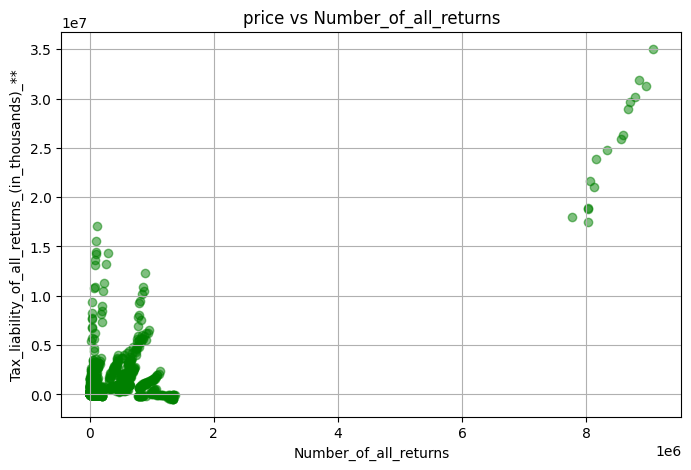

Correlation between number_of_all_returns and tax_liability_of_all_returns_(in_thousands)_**: 0.83


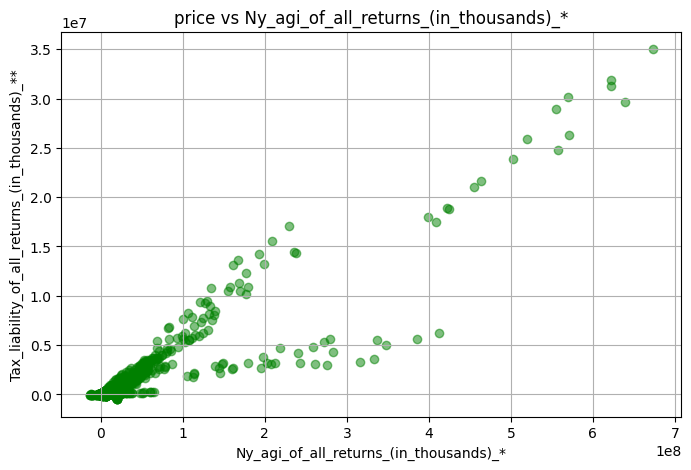

Correlation between ny_agi_of_all_returns_(in_thousands)_* and tax_liability_of_all_returns_(in_thousands)_**: 0.93


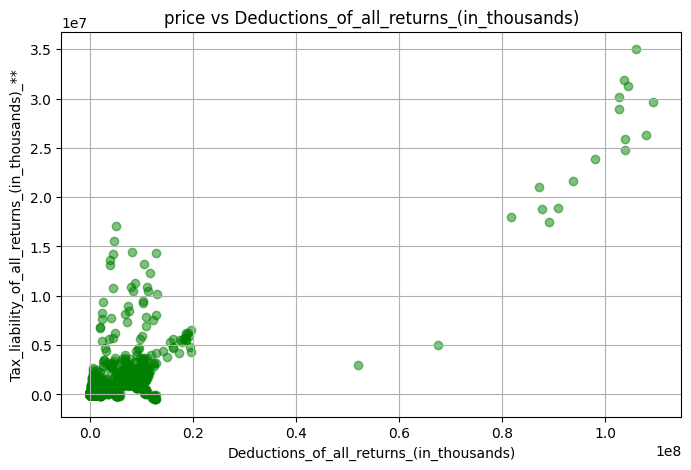

Correlation between deductions_of_all_returns_(in_thousands) and tax_liability_of_all_returns_(in_thousands)_**: 0.87


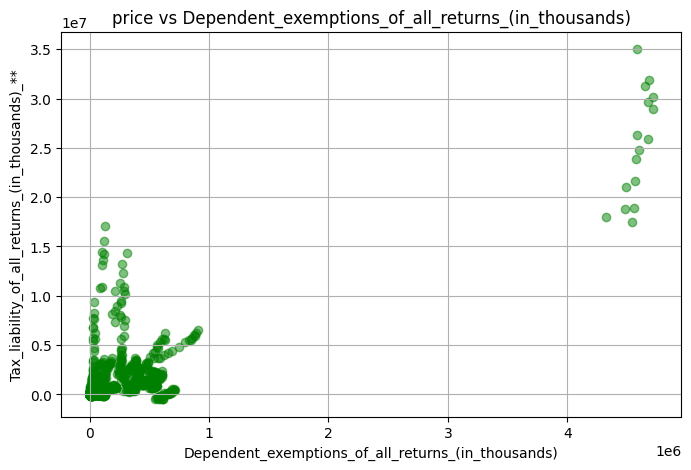

Correlation between dependent_exemptions_of_all_returns_(in_thousands) and tax_liability_of_all_returns_(in_thousands)_**: 0.84


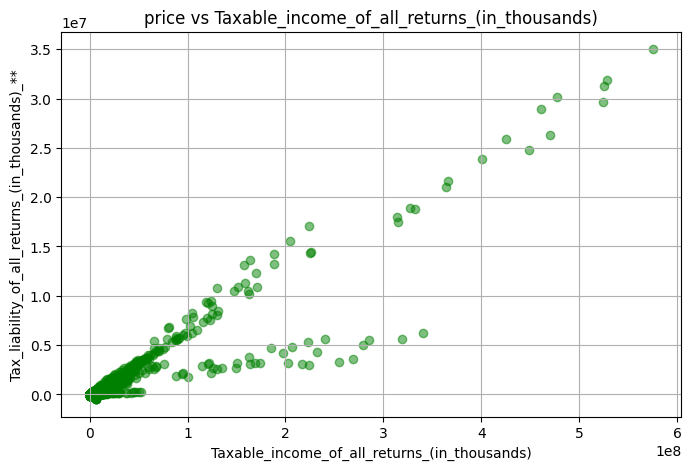

Correlation between taxable_income_of_all_returns_(in_thousands) and tax_liability_of_all_returns_(in_thousands)_**: 0.94


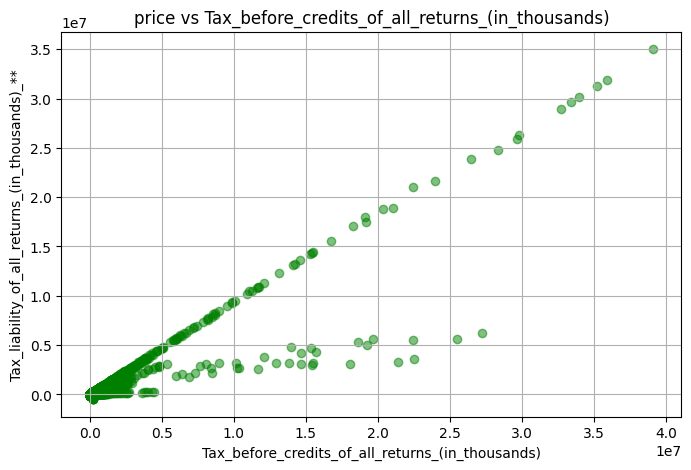

Correlation between tax_before_credits_of_all_returns_(in_thousands) and tax_liability_of_all_returns_(in_thousands)_**: 0.92


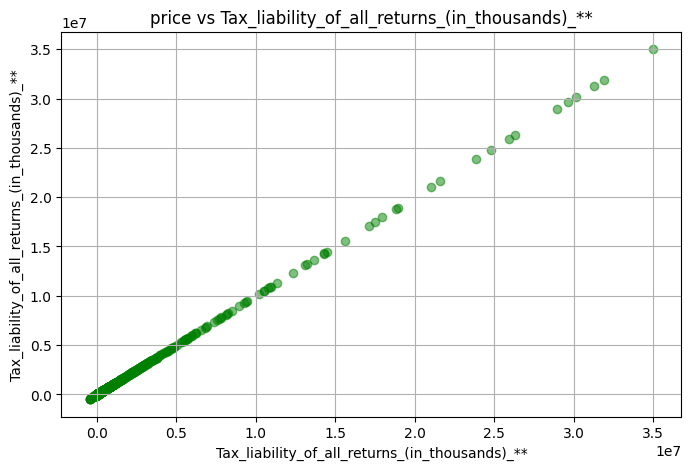

Correlation between tax_liability_of_all_returns_(in_thousands)_** and tax_liability_of_all_returns_(in_thousands)_**: 1.00


In [ ]:
#target column is  tax_liability_of_all_returns_(in_thousands)_**
target = 'tax_liability_of_all_returns_(in_thousands)_**'
num_cols = ['number_of_all_returns', 'ny_agi_of_all_returns_(in_thousands)_*', 'deductions_of_all_returns_(in_thousands)', 'dependent_exemptions_of_all_returns_(in_thousands)', 'taxable_income_of_all_returns_(in_thousands)', 'tax_before_credits_of_all_returns_(in_thousands)', 'tax_liability_of_all_returns_(in_thousands)_**']

for col in num_cols:
  plt.figure(figsize=(8, 5))
  plt.scatter(df[col], df[target], alpha=0.5, color='green')
  plt.title(f'price vs {col.capitalize()}')
  plt.xlabel(col.capitalize())
  plt.ylabel(target.capitalize())
  plt.grid(True)
  #plt.savefig(f"{col}_vs_tax_liability_of_all_returns_(in_thousands)_**_NUM_NUM.png", dpi=300, bbox_inches="tight")  # save as PNG
  plt.show()
  corr = df[[col, target]].corr().iloc[0,1]
  print(f"Correlation between {col} and {target}: {corr:.2f}")

#Bivariate Analysis (numeric-categorical)


Statistical Summary for income_class vs tax_liability_of_all_returns_(in_thousands)_** 
                   count       mean   median       min         max         std
income_class                                                                  
Total               1816  526276.40  34077.5     147.0  35011775.0  2580621.21
100,000 - 199,999   1802  100245.31   6237.5       9.0   6567497.0   487263.60
75,000 - 99,999     1784   43538.32   4524.0       4.0   2476512.0   213825.38
60,000 - 74,999     1784   28497.68   3450.0       1.0   1542664.0   141346.26
50,000 - 59,999     1777   19054.00   2372.0       1.0   1042047.0    95184.66
40,000 - 49,999     1793   17937.64   2254.0     -33.0   1002229.0    90788.55
30,000 - 39,999     1802   13924.97   1848.5     -37.0    916843.0    71662.81
20,000 - 29,999     1806    4850.41    592.5  -16396.0    536980.0    28558.62
5,000 - 9,999       1795   -2690.55   -185.0 -188932.0      1409.0    15012.98
10,000 - 19,999     1809   -5459.97      2

/tmp/ipython-input-2727088287.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=plot_df, palette='Set2')


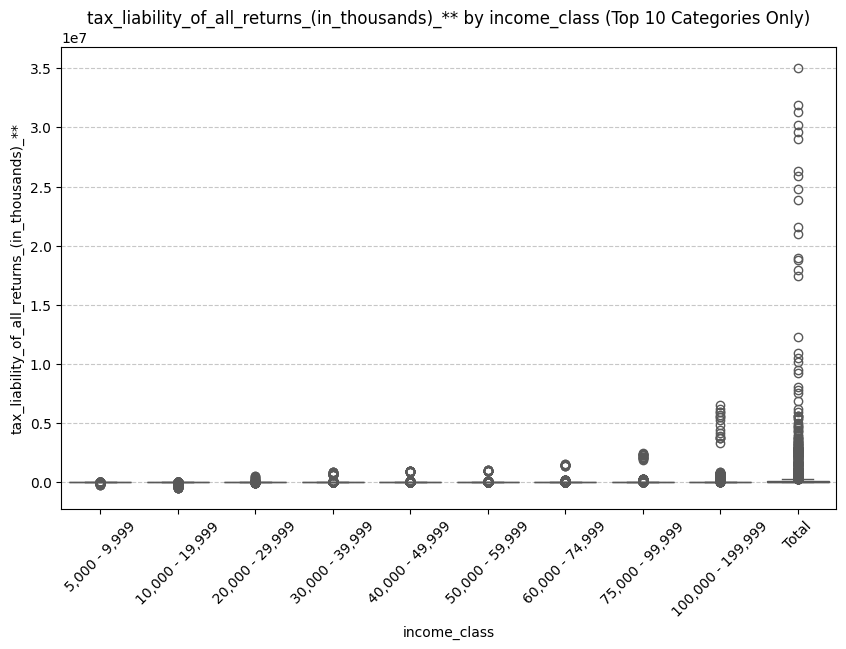


Statistical Summary for resident_type vs tax_liability_of_all_returns_(in_thousands)_** 
                       count       mean   median       min         max  \
resident_type                                                            
Full-Year Resident     13420  120318.71   3570.5 -467479.0  35011775.0   
Part-Year Resident       208   77154.45  18748.0   -1130.0    715805.0   
Full-Year Nonresident   9578   29296.51    156.5   -5502.0   6184372.0   

                              std  
resident_type                      
Full-Year Resident     1085154.54  
Part-Year Resident      139142.02  
Full-Year Nonresident   249833.41  


/tmp/ipython-input-2727088287.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=plot_df, palette='Set2')


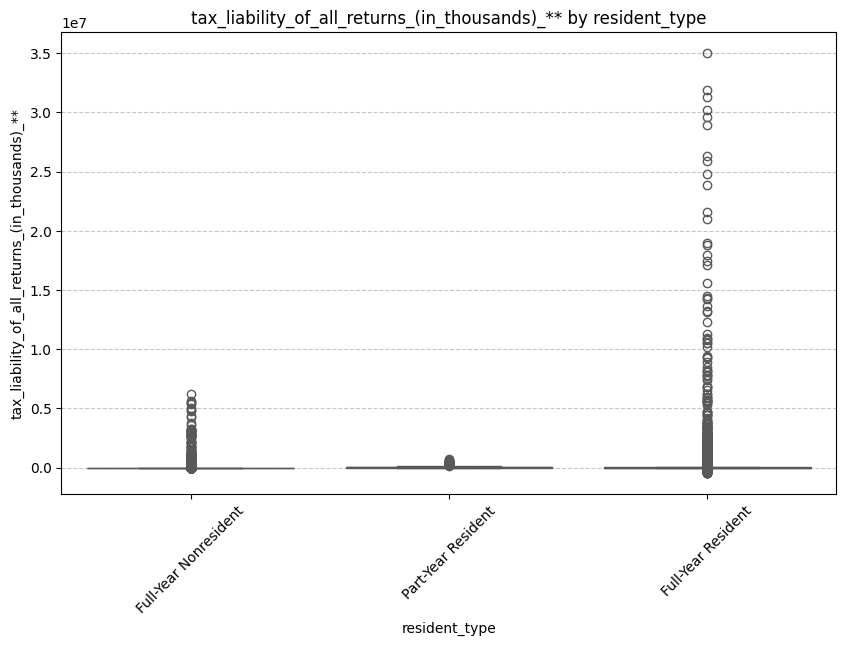


Statistical Summary for state vs tax_liability_of_all_returns_(in_thousands)_** 
                          count       mean   median       min         max  \
state                                                                       
All - Excluding New York    416  375845.09  33561.5   -5502.0   6184372.0   
New Jersey                  208  352817.46  40869.5   -1800.0   3132041.0   
New York                  13420  120318.71   3570.5 -467479.0  35011775.0   
Pennsylvania                208   21611.38   5490.0   -2262.0    201332.0   
Massachusetts               208   10705.10    560.5    -436.0    127741.0   
Illinois                    208    7461.43    199.0    -470.0     82998.0   
Virginia                    208    5765.61    257.5      -8.0     63069.0   
Texas                       208    5520.46    266.5    -354.0     64706.0   
Not Applicable             1615    5152.63    191.0   -1483.0    222793.0   
Colorado                    208    2143.85     89.0    -602.0     26459

/tmp/ipython-input-2727088287.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=plot_df, palette='Set2')


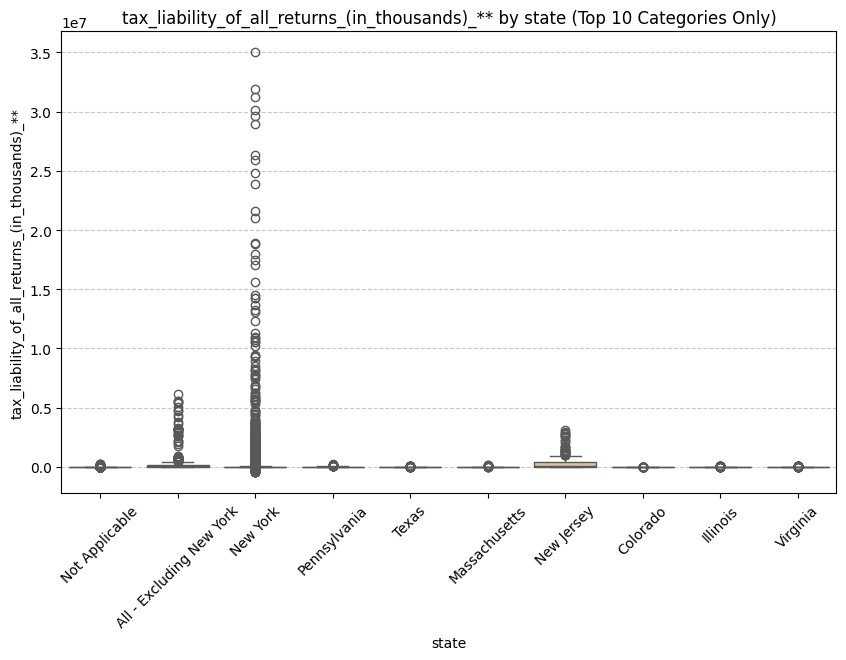


Statistical Summary for county vs tax_liability_of_all_returns_(in_thousands)_** 
                                    count       mean   median     min  \
county                                                                  
Grand Total, Full-Year Nonresident    208  674535.74  60626.5 -5502.0   
Grand Total, Part-Year Resident       208   77154.45  18748.0 -1130.0   
Onondaga                              208   60604.63  24193.0 -8793.0   
Dutchess                              208   49210.24  14853.0 -3610.0   
Saratoga                              208   38312.29  12653.5 -1254.0   
All                                  7755   17018.31    139.0 -2432.0   
Ontario                               208   14147.65   5502.5 -1297.0   
Clinton                               208    7235.05   3727.0  -945.0   
Not Applicable                       1615    5152.63    191.0 -1483.0   
Washington                            208    4473.51   2616.5 -1036.0   

                                        

/tmp/ipython-input-2727088287.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=plot_df, palette='Set2')


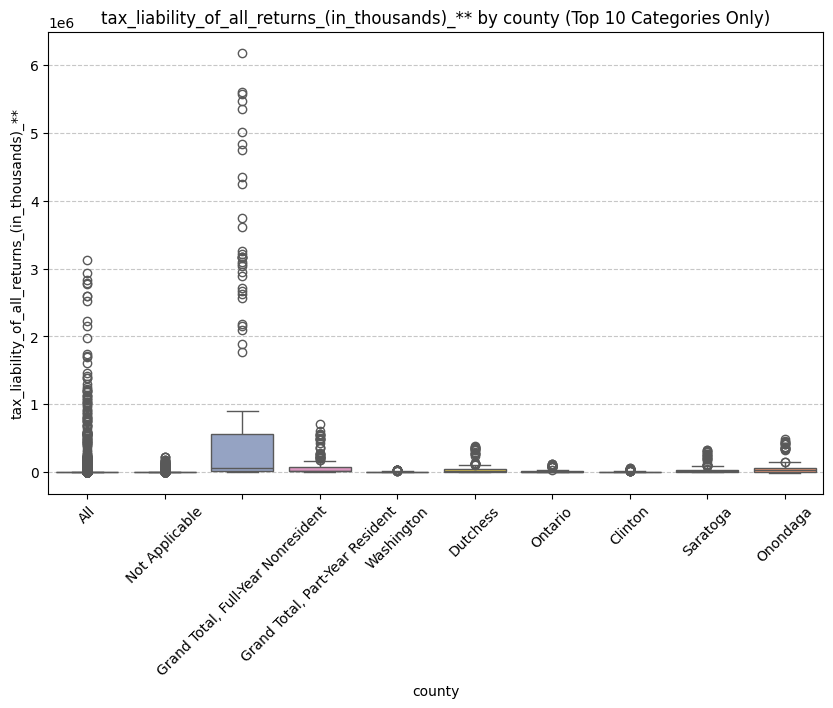


Statistical Summary for country vs tax_liability_of_all_returns_(in_thousands)_** 
                         count       mean   median       min         max  \
country                                                                    
All                        416  375845.09  33561.5   -5502.0   6184372.0   
United States            21131   82658.21   1620.0 -467479.0  35011775.0   
Residence Unknown ++++     208   23424.08   2886.0    -230.0    222793.0   
All Other Countries +++    203    7498.33    693.0   -1483.0     74654.0   
Ireland                    123    1546.77     41.0     -17.0     29951.0   
Canada                     193    1528.04    361.0     -10.0     16541.0   
Germany                    180    1484.14    117.5     -20.0     36146.0   
China                      130    1081.66     76.5       1.0     15861.0   
France                     111    1061.15     52.0       0.0     12778.0   
Japan                      107     721.89     36.0       0.0      7599.0   

   

/tmp/ipython-input-2727088287.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y=target, data=plot_df, palette='Set2')


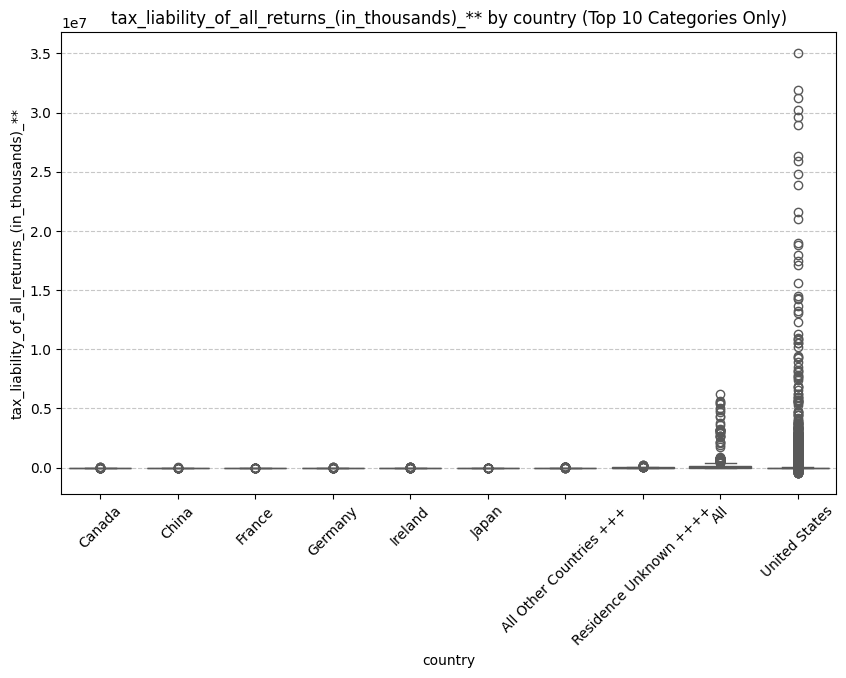

In [ ]:
target = 'tax_liability_of_all_returns_(in_thousands)_**'
cat_cols = ['income_class', 'resident_type', 'state', 'county', 'country']

for col in cat_cols:
    if df[col].nunique() > 10:
        top10_categories = df[col].value_counts().nlargest(10).index.tolist()
        plot_df = df[df[col].isin(top10_categories)].copy()
        summary = (
        plot_df.groupby(col)[target]
        .agg(['count', 'mean', 'median', 'min', 'max', 'std'])
        .sort_values(by=['mean','count'], ascending=[False,False])
        .round(2)
        )
        print(f"\nStatistical Summary for {col} vs {target} ")
        print(summary)
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=col, y=target, data=plot_df, palette='Set2')
        plt.title(f'{target} by {col} (Top 10 Categories Only)')
    else:
        plot_df = df.copy()
        summary = (
        plot_df.groupby(col)[target]
        .agg(['count', 'mean', 'median', 'min', 'max', 'std'])
        .sort_values(by=['mean','count'], ascending=[False,False])
        .round(2)
        )
        print(f"\nStatistical Summary for {col} vs {target} ")
        print(summary)
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=col, y=target, data=plot_df, palette='Set2')
        plt.title(f'{target} by {col}')

    plt.xlabel(col)
    plt.ylabel(target)
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    #plt.savefig(f"{col}_vs_profit_CAT_NUM.png", dpi=300, bbox_inches="tight")  # save as PNG
    plt.show()


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23206 entries, 4 to 23734
Data columns (total 16 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   tax_year                                            23206 non-null  int64  
 1   resident_type                                       23206 non-null  object 
 2   place_of_residence                                  23206 non-null  object 
 3   country                                             23206 non-null  object 
 4   state                                               23206 non-null  object 
 5   county                                              23206 non-null  object 
 6   income_class                                        23206 non-null  object 
 7   number_of_all_returns                               23206 non-null  float64
 8   ny_agi_of_all_returns_(in_thousands)_*              23206 non-null  float64
 9   

In [ ]:
df['taxable_income_of_all_returns_(in_thousands)'].describe()

,taxable_income_of_all_returns_(in_thousands)
count,2.320600e+04
mean,1.769674e+06
std,1.541119e+07
min,1.200000e+01
25%,5.226750e+03
50%,4.951350e+04
75%,2.650005e+05
max,5.755124e+08
